In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import sigpy as sp
import sigpy.plot as pl
import numpy as np
import os

In [2]:
os.listdir("/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project")

ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")

In [3]:
print("k space array shape: {}".format(ksp.shape))
print("coordinate array shape: {}".format(coord.shape))

dcf = (coord[...,0]**2 + coord[...,1]**2)**0.5

img_grid = sp.nufft_adjoint(dcf*ksp, coord)

img_rss = np.sum(np.abs(img_grid)**2, axis=0)**0.5
#pl.ImagePlot(img_rss, title='test')

k space array shape: (12, 96, 512)
coordinate array shape: (96, 512, 2)


## Goal: Generate Single coil dataset from 12 coil dataset

**Objectives:**

1. Use the density compensation function, k-space data, and trajectory coordinates to reconstruct image.
2. Apply a non-uniform fast Fourier transform (NUFFT) to convert the reconstructed image back into a single k-space dataset.


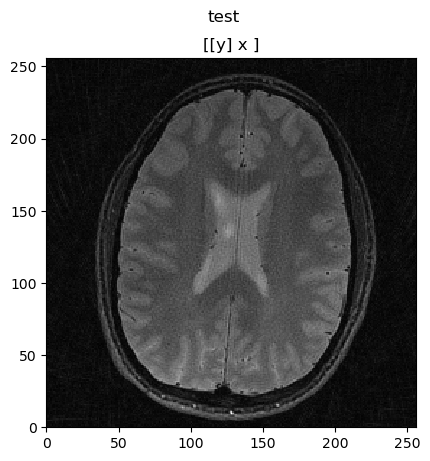

In [4]:
dcf = (coord[...,0]**2 + coord[...,1]**2)**0.5

img_grid = sp.nufft_adjoint(dcf*ksp, coord)

img_rss = np.sum(np.abs(img_grid)**2, axis=0)**0.5


img_complex = img_rss.astype(complex)
ksp_combined = sp.nufft(img_complex, coord)



img_grid2 = sp.nufft_adjoint(ksp_combined * dcf, coord)
img2 = np.abs(img_grid2)
pl.ImagePlot(img_rss, title='test')


## Goal: Generate Radial Data

**Objectives:**

1. For each spoke, bifurcate at midpoint then flip FIRST spoke
2. Move second spoke to len(spokes) + 1
3. Do same thing for coord data
4. Extend by converting coord data cartesian --> polar??

In [5]:
'''n_spokes, n_points, n_dims = coord.shape
half = n_points // 2

ksp_new = np.zeros((n_spokes *2, half), dtype=ksp.dtype)
coord_new = np.zeros((n_spokes * 2, half, 2), dtype=coord.dtype)'''

'n_spokes, n_points, n_dims = coord.shape\nhalf = n_points // 2\n\nksp_new = np.zeros((n_spokes *2, half), dtype=ksp.dtype)\ncoord_new = np.zeros((n_spokes * 2, half, 2), dtype=coord.dtype)'

In [6]:
def spoke_split(kspacedata, coords):
    halfwaypoint = kspacedata.shape[0] // 2
    
    spoke_a = np.flip(kspacedata[:halfwaypoint], axis=0)
    spoke_b = kspacedata[halfwaypoint:]
    
    coords_a = np.flip(coords[:halfwaypoint, :], axis=0)
    coords_b = coords[halfwaypoint:, :]
    
    return spoke_a, spoke_b, coords_a, coords_b


def get_spoke_b_index(spoke_index, n_spokes):
    return n_spokes + spoke_index

def generate_radial_data(ksp, coord):
    n_spokes, n_points, n_dims = coord.shape
    half = n_points // 2

    ksp_new = np.zeros((n_spokes * 2, half), dtype=ksp.dtype)
    coord_new = np.zeros((n_spokes * 2, half, n_dims), dtype=coord.dtype)

    for spoke_index in range(n_spokes):
        spoke_a, spoke_b, coords_a, coords_b = spoke_split(ksp[spoke_index], coord[spoke_index])
        
        b_index = get_spoke_b_index(spoke_index, n_spokes)

        ksp_new[spoke_index] = spoke_a
        ksp_new[b_index] = spoke_b

        coord_new[spoke_index] = coords_a
        coord_new[b_index] = coords_b

    return ksp_new, coord_new
radial_kspace, radial_coords = generate_radial_data(ksp=ksp_combined, coord=coord)

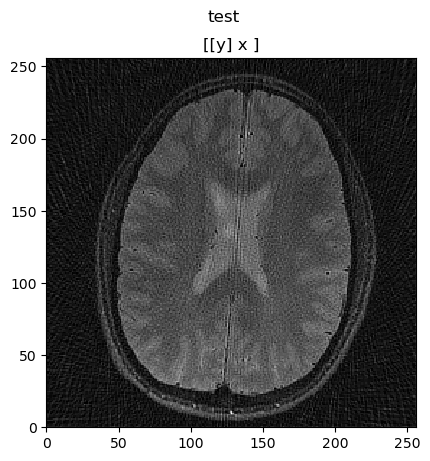

In [7]:
dcf = np.sqrt(radial_coords[..., 0]**2 + radial_coords[..., 1]**2)
img_grid = sp.nufft_adjoint(radial_kspace * dcf, radial_coords)
img = np.abs(img_grid)
pl.ImagePlot(img, title='test')

## Goal: Simulate a deadtime gap

**Objectives:**

1. For each spoke, remove n points
2. Do same thing for coord data
3. Plot

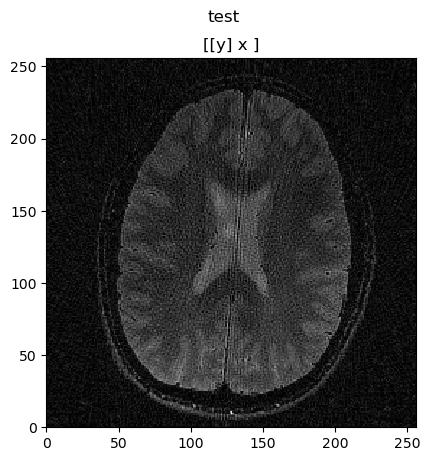

In [8]:
def point_remove(kspacedata, coord_data, n):
    return kspacedata[:,n:], coord_data[:,n:,:]


dead_time_kspace, dead_time_radial_coords = point_remove(kspacedata=radial_kspace, coord_data=radial_coords, n=1)

dcf = np.sqrt(dead_time_radial_coords[..., 0]**2 + dead_time_radial_coords[..., 1]**2)
img_grid = sp.nufft_adjoint(dead_time_kspace * dcf, dead_time_radial_coords)

img = np.abs(img_grid)
pl.ImagePlot(img, title='test')

## Goal: Remove Spokes

**Objectives:**

1. For n spokes, remove n/2 spokes
2. Do same thing for coord data
3. Plot

In [9]:
radial_kspace, radial_coords = generate_radial_data(ksp=ksp_combined, coord=coord)
print(radial_coords.shape)
print(radial_kspace.shape)

(192, 256, 2)
(192, 256)


In [10]:
def spoke_remove(kspacedata, coord_data, unsampling):
    return kspacedata[::unsampling], coord_data[::unsampling]
reduced_spokes_kspace, reduced_spokes_radial_coords = spoke_remove(kspacedata=radial_kspace, coord_data=radial_coords, unsampling=2)

dcf = np.sqrt(reduced_spokes_radial_coords[..., 0]**2 + reduced_spokes_radial_coords[..., 1]**2)
reduced_spokes_img_grid = sp.nufft_adjoint(reduced_spokes_kspace * dcf, reduced_spokes_radial_coords)

reduced_spokes_img = np.abs(reduced_spokes_img_grid)
#pl.ImagePlot(reduced_spokes_img, title='test')

## Goal: Combine All Functions

**Objectives:**

1. Put all functions into one ZTE dataset generator
2. Use 12 channel array rather than 1 channel toy array
3. Plot

In [11]:
def spoke_split(kspacedata, coords):
    halfwaypoint = kspacedata.shape[0] // 2
    
    spoke_a = np.flip(kspacedata[:halfwaypoint], axis=0)
    spoke_b = kspacedata[halfwaypoint:]
    
    coords_a = np.flip(coords[:halfwaypoint, :], axis=0)
    coords_b = coords[halfwaypoint:, :]
    
    return spoke_a, spoke_b, coords_a, coords_b

def get_spoke_b_index(spoke_index, n_spokes):
    return n_spokes + spoke_index

def spoke_remove(kspacedata, coord_data, unsampling):
    return kspacedata[::unsampling], coord_data[::unsampling]

def point_remove(kspacedata, coord_data, n):
    return kspacedata[:,n:], coord_data[:,n:,:]


def generate_zte_data(ksp, coord,n_missing,undersampling_factor):

    n_spokes, n_points, n_dims = coord.shape
    half = n_points // 2

    ksp_new = np.zeros((n_spokes * 2, half), dtype=ksp.dtype)
    coord_new = np.zeros((n_spokes * 2, half, n_dims), dtype=coord.dtype)

    for spoke_index in range(n_spokes):
        spoke_a, spoke_b, coords_a, coords_b = spoke_split(ksp[spoke_index], coord[spoke_index])
        
        b_index = get_spoke_b_index(spoke_index, n_spokes)

        ksp_new[spoke_index] = spoke_a
        ksp_new[b_index] = spoke_b

        coord_new[spoke_index] = coords_a
        coord_new[b_index] = coords_b

    ksp_new, coord_new = point_remove(kspacedata=ksp_new, coord_data=coord_new, n=n_missing)
    ksp_new, coord_new = spoke_remove(kspacedata=ksp_new, coord_data=coord_new, unsampling=undersampling_factor)

    return ksp_new, coord_new

zte_radial_kspace, zte_radial_coords = generate_zte_data(ksp=ksp_combined, coord=coord,n_missing=1, undersampling_factor=1)

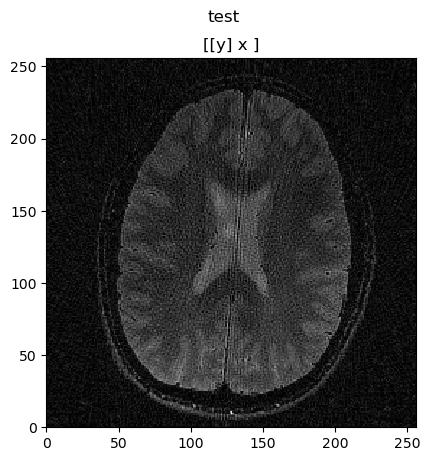

In [12]:
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)
zte_img_grid = sp.nufft_adjoint(zte_radial_kspace * dcf, zte_radial_coords)

reduced_spokes_img = np.abs(zte_img_grid)
pl.ImagePlot(reduced_spokes_img, title='test')

In [13]:
def spoke_split(kspacedata, coords):
    halfwaypoint = kspacedata.shape[0] // 2
    
    spoke_a = np.flip(kspacedata[:halfwaypoint], axis=0)
    spoke_b = kspacedata[halfwaypoint:]
    
    coords_a = np.flip(coords[:halfwaypoint, :], axis=0)
    coords_b = coords[halfwaypoint:, :]
    
    return spoke_a, spoke_b, coords_a, coords_b

def get_spoke_b_index(spoke_index, n_spokes):
    return n_spokes + spoke_index

def spoke_remove(kspacedata, coord_data, unsampling):
    return kspacedata[:,::unsampling], coord_data[::unsampling]

def point_remove(kspacedata, coord_data, n):
    return kspacedata[:,:,n:], coord_data[:,n:,:]


def generate_zte_data(ksp, coord,n_missing,undersampling_factor=1):

    n_spokes, n_points, n_dims = coord.shape
    n_coils = ksp.shape[0]
    half = n_points // 2

    ksp_new = np.zeros((n_coils,n_spokes * 2, half), dtype=ksp.dtype)
    coord_new = np.zeros((n_spokes * 2, half, n_dims), dtype=coord.dtype)
    
    for coil_index in range(n_coils):
        for spoke_index in range(n_spokes):
            spoke_a, spoke_b, coords_a, coords_b = spoke_split(ksp[coil_index,spoke_index], coord[spoke_index])
            
            b_index = get_spoke_b_index(spoke_index, n_spokes)

            ksp_new[coil_index, spoke_index] = spoke_a
            ksp_new[coil_index,b_index] = spoke_b

            coord_new[spoke_index] = coords_a
            coord_new[b_index] = coords_b

    ksp_new, coord_new = point_remove(kspacedata=ksp_new, coord_data=coord_new, n=n_missing)
    ksp_new, coord_new = spoke_remove(kspacedata=ksp_new, coord_data=coord_new, unsampling=undersampling_factor)

    return ksp_new, coord_new

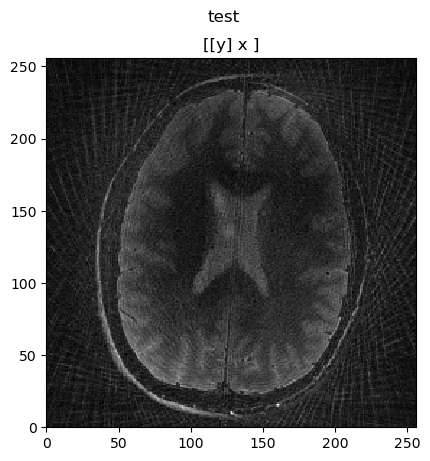

In [14]:
zte_radial_kspace, zte_radial_coords = generate_zte_data(ksp=ksp, coord=coord,n_missing=2, undersampling_factor=2)
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)
zte_img_grid = sp.nufft_adjoint(zte_radial_kspace * dcf, zte_radial_coords)
img_rss = np.sum(np.abs(zte_img_grid)**2, axis=0)**0.5
pl.ImagePlot(img_rss, title='test')

## Goal: Isolate 1 Spoke

**Objectives:**

1. 1 spoke, 1 coil => 512 len array
2. Copy and add gap size of x

In [15]:
from scipy.linalg import hankel

spoke_test = ksp[0,0,:]
spoke_gap = spoke_test.copy()
gap = 2
spoke_gap[:gap] = 0

## Goal: Hankel Operator Function

**Objectives:**

1. Create empty array (H), slide window across
2. For each window add a new row to H
3. Call hankel with specified gap size

In [ ]:
def hankel (k, w):
    N = len(k)
    H = []

    for i in range (N - w + 1):
        row = []

        for j in range (w):
            row.append(k[i+j])
        H.append(row)
    return (H)

h1 = hankel(k=spoke_gap, w=5)
h1=np.array(h1)



## Goal: Singular Value Thresholding

**Objectives:**

1. Call hankel with specified gap size
2. Use np.linalg.svd to perform SVD on H
3. Reconstruct but only keep values above 1.5%
np.linalg.svd(A) - full_matrices??

In [17]:
def svt(A, thresh):
    U, Sigma, Vtrans = np.linalg.svd(A)
    largest_singularvalue = Sigma[0]
    threshold_value = thresh * largest_singularvalue
    Sigma[Sigma < threshold_value] = 0
    return np.matmul(np.matmul(U, np.diag(Sigma)), Vtrans)